<h1>Train — ResNet-50</h1>

Trains and evaluates ResNet-50 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet50"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1829 | Val: 446 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet50"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-50: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-50: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-50)
# ---------------------------------------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-50] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[ResNet-50] Epoch   1/100 | LR: 3.77e-04 | train loss 0.9074 acc 0.583 | val loss 0.7744 acc 0.702 *


[ResNet-50] Epoch   2/100 | LR: 3.77e-04 | train loss 0.6097 acc 0.733 | val loss 0.6272 acc 0.760 *


[ResNet-50] Epoch   3/100 | LR: 3.77e-04 | train loss 0.4865 acc 0.791 | val loss 0.6261 acc 0.789 *


[ResNet-50] Epoch   4/100 | LR: 3.77e-04 | train loss 0.4030 acc 0.827 | val loss 0.5059 acc 0.814 *


...

[ResNet-50] Epoch  16/100 | LR: 3.77e-04 | train loss 0.1512 acc 0.934 | val loss 0.4772 acc 0.850


[ResNet-50] Epoch  17/100 | LR: 3.77e-05 | train loss 0.1071 acc 0.958 | val loss 0.5965 acc 0.827


[ResNet-50] Epoch  18/100 | LR: 3.77e-05 | train loss 0.0805 acc 0.962 | val loss 0.4628 acc 0.870


[ResNet-50] Epoch  19/100 | LR: 3.77e-05 | train loss 0.0540 acc 0.979 | val loss 0.4383 acc 0.870


[ResNet-50] Epoch  20/100 | LR: 3.77e-05 | train loss 0.0509 acc 0.976 | val loss 0.4360 acc 0.883

[ResNet-50] No val loss improvement for 10 epochs — stopping early at epoch 20.

[ResNet-50] Restored best checkpoint (val loss = 0.4242)


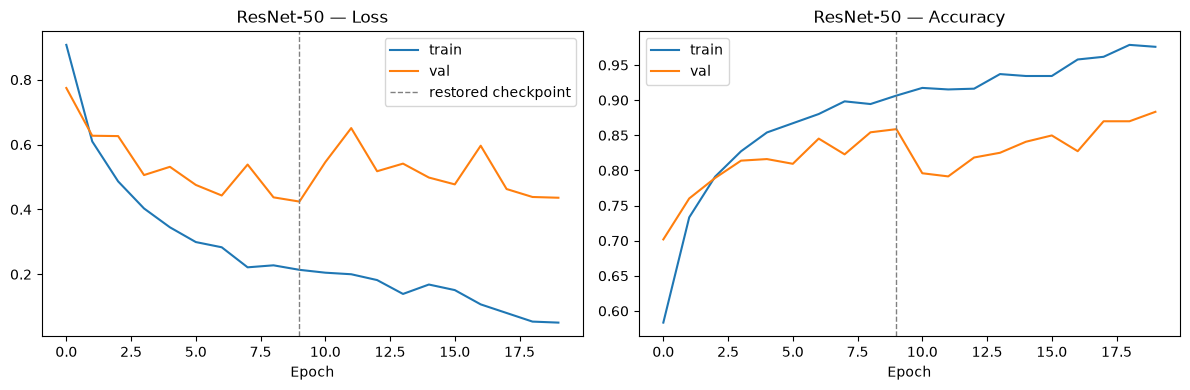

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-50", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-50")

## Evaluate on the test set

[ResNet-50] Test accuracy: 0.758


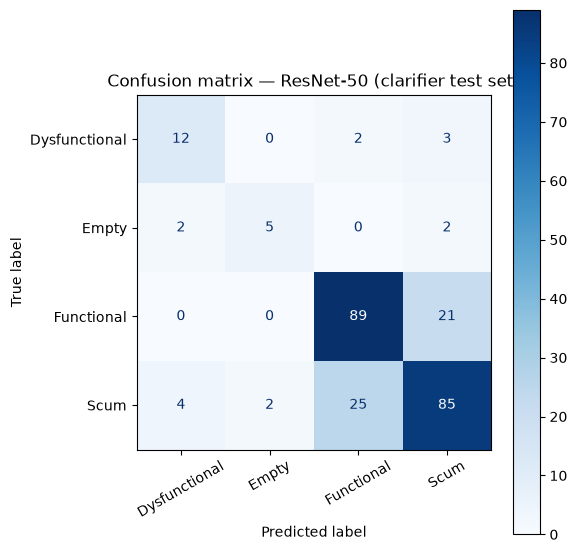

               precision    recall  f1-score   support

Dysfunctional      0.667     0.706     0.686        17
        Empty      0.714     0.556     0.625         9
   Functional      0.767     0.809     0.788       110
         Scum      0.766     0.733     0.749       116

     accuracy                          0.758       252
    macro avg      0.728     0.701     0.712       252
 weighted avg      0.758     0.758     0.757       252



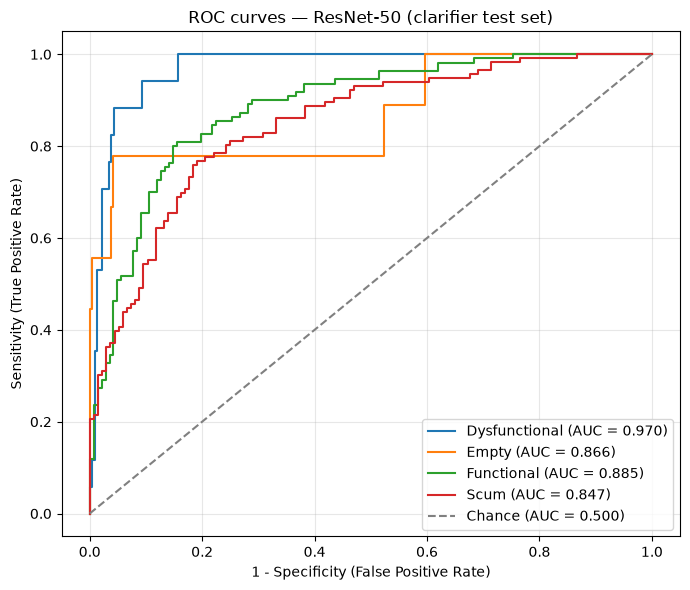

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.970
  Empty          : 0.866
  Functional     : 0.885
  Scum           : 0.847

Mean AUC (over 4/4 classes with test examples): 0.892


(np.float64(0.7579365079365079),
 {'Dysfunctional': 0.9702127659574468,
  'Empty': 0.8664837677183357,
  'Functional': 0.8845070422535211,
  'Scum': 0.8474898580121704})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-50", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ResNet-50", "resnet50")

Saved results to ../results/clarifier_aug/results_clarifier_resnet50_Fisantekraal.pkl
Saved model weights to ../models/clarifier_resnet50_cnn.pt
